In [ ]:
import pandas as pd

df = pd.read_csv("../data/cleaned.csv")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,144,A,Minor,65,23,80,14,63,11,6


### Feature Selection

We selected the following features for clustering:
- danceability
- energy
- valence
- tempo (BPM)

These features describe the musical characteristics of songs, such as how energetic, positive, and danceable they are. They are suitable for clustering because they capture the style and mood of the music rather than popularity.

In [ ]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Find columns dynamically
dance_col = next(c for c in df.columns if "dance" in c)
energy_col = next(c for c in df.columns if "energy" in c)
valence_col = next(c for c in df.columns if "valence" in c)
tempo_col = next(c for c in df.columns if "bpm" in c or "tempo" in c)

# Convert to numeric
for col in [dance_col, energy_col, valence_col, tempo_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing values
df = df.dropna(subset=[dance_col, energy_col, valence_col, tempo_col])

# Feature matrix
X = df[[dance_col, energy_col, valence_col, tempo_col]]

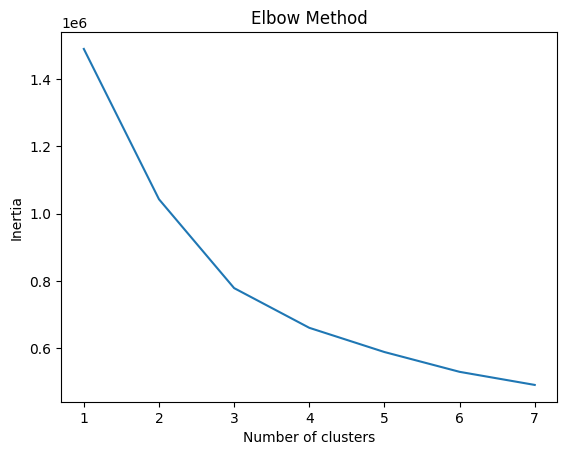

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(1, 8), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# KMeans
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X)

# DBSCAN (second algorithm)
dbscan = DBSCAN(eps=3, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X)

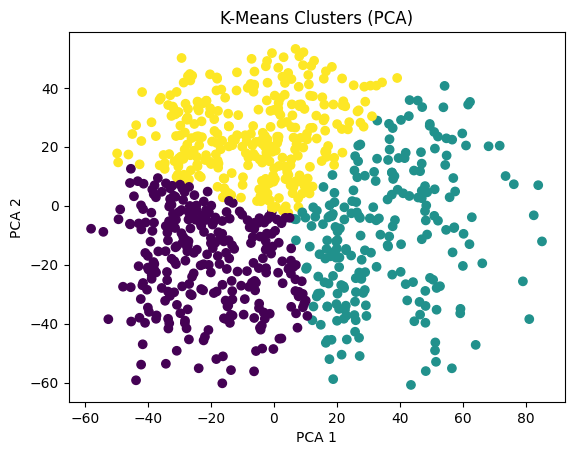

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'])
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
cluster_summary = df.groupby('cluster_kmeans')[X.columns].mean()
cluster_summary

,danceability_%,energy_%,valence_%,bpm
cluster_kmeans,,,,
0,63.829787,58.542553,33.641844,101.982270
1,59.748879,61.789238,44.035874,157.717489
2,76.147910,71.469453,72.186495,116.064309


### Cluster Interpretation

Cluster 0 – **Energetic & Danceable**
High energy, high danceability, higher tempo. Suitable for parties.

Cluster 1 – **Calm & Emotional**
Lower energy and tempo, often lower valence. More relaxed or emotional songs.

Cluster 2 – **Balanced**
Moderate values across all features. A mix between energetic and calm styles.

### Interpretation

The clustering results show that songs can be grouped into three main segments based on their musical characteristics. The first cluster represents energetic and danceable tracks with high energy, danceability, and tempo. These songs are typically suitable for parties or active listening environments. The second cluster includes calmer and more emotional songs, characterized by lower energy, tempo, and valence. These tracks are more suitable for relaxed or reflective listening. The third cluster represents a balanced group, with moderate values across all features, combining elements of both energetic and calm songs.

The separation between clusters is moderately clear but not perfect. While the PCA visualization shows some distinct grouping, there is noticeable overlap between clusters. This indicates that musical characteristics exist on a continuum rather than in strictly separated groups. Therefore, while clustering captures general patterns in the data, the boundaries between segments remain somewhat ambiguous.

In [ ]:
# Final label for Task 4
df['cluster_label'] = df['cluster_kmeans']

df.to_csv("../data/clustered.csv", index=False)